# CIFAR10-DVS Dataset Inspection

This notebook inspects the CIFAR10-DVS dataset, checks the current preprocessing assumptions, and visualizes event-to-frame conversions for the first project milestone.

> Note: when you run the dataset loading cells for the first time, Tonic may download the dataset into `data/raw/` if it is not already present.

## Goals

- confirm that the project package imports correctly from `src/`
- load CIFAR10-DVS through Tonic
- inspect dataset size, labels, and event structure
- convert a sample to dense frames and visualize selected time bins

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

PROJECT_ROOT

PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject')

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from snn_cifar10dvs.config import CIFAR10DVSConfig, ProjectPaths
from snn_cifar10dvs.data import get_class_distribution, load_cifar10dvs
from snn_cifar10dvs.preprocessing import FrameTransformConfig, build_frame_transform

paths = ProjectPaths()
dataset_config = CIFAR10DVSConfig()
paths

ProjectPaths(root_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject'), data_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/data'), raw_data_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/data/raw'), processed_data_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/data/processed'), notebooks_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/notebooks'), scripts_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/scripts'), outputs_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs'), checkpoints_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs/checkpoints'), figures_dir=PosixPath('/home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/outputs

## Raw Dataset Loading

In [4]:
raw_dataset = load_cifar10dvs(paths=paths)
len(raw_dataset)

Using downloaded and verified file: /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/data/raw/CIFAR10DVS/CIFAR10DVS.zip
Extracting /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/data/raw/CIFAR10DVS/CIFAR10DVS.zip to /home/asen/Work/Uni Work/Година 3/Семестър 6/Невронни Мрежи/CourseProject/data/raw/CIFAR10DVS


10000

In [5]:
class_names = list(raw_dataset.classes)
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [6]:
class_distribution = get_class_distribution(raw_dataset)
{class_names[class_id]: count for class_id, count in class_distribution.items()}

{'airplane': 1000,
 'automobile': 1000,
 'bird': 1000,
 'cat': 1000,
 'deer': 1000,
 'dog': 1000,
 'frog': 1000,
 'horse': 1000,
 'ship': 1000,
 'truck': 1000}

## Raw Sample Inspection

In [8]:
sample_index = 0
events, target = raw_dataset[sample_index]

print("target index:", target)
print("target label:", class_names[target])
print("num events:", len(events))
print("event dtype:", events.dtype)
events[:5]

target index: 0
target label: airplane
num events: 210816
event dtype: [('t', '<u8'), ('x', '<u2'), ('y', '<u2'), (('on', 'p'), '?')]


array([( 0, 64,  18, False), ( 5, 22,  59,  True), (24, 22, 126,  True),
       (29, 23,  41,  True), (39, 64,  15, False)],
      dtype=[('t', '<u8'), ('x', '<u2'), ('y', '<u2'), (('on', 'p'), '?')])

In [9]:
event_summary = {
    "x_min": int(events["x"].min()),
    "x_max": int(events["x"].max()),
    "y_min": int(events["y"].min()),
    "y_max": int(events["y"].max()),
    "t_min": int(events["t"].min()),
    "t_max": int(events["t"].max()),
    "polarities": np.unique(events["p"]).tolist(),
}
event_summary

{'x_min': 0,
 'x_max': 127,
 'y_min': 0,
 'y_max': 127,
 't_min': 0,
 't_max': 1271387,
 'polarities': [False, True]}

## Event-to-Frame Transformation

In [10]:
frame_config = FrameTransformConfig(
    sensor_size=dataset_config.sensor_size,
    n_time_bins=10,
    normalize=True,
)
frame_transform = build_frame_transform(frame_config)

framed_dataset = load_cifar10dvs(paths=paths, transform=frame_transform)
frames, frame_target = framed_dataset[sample_index]

print("frame target:", frame_target, class_names[frame_target])
print("frame tensor shape:", tuple(frames.shape))
frames.dtype

frame target: 0 airplane
frame tensor shape: (10, 2, 128, 128)


torch.float32

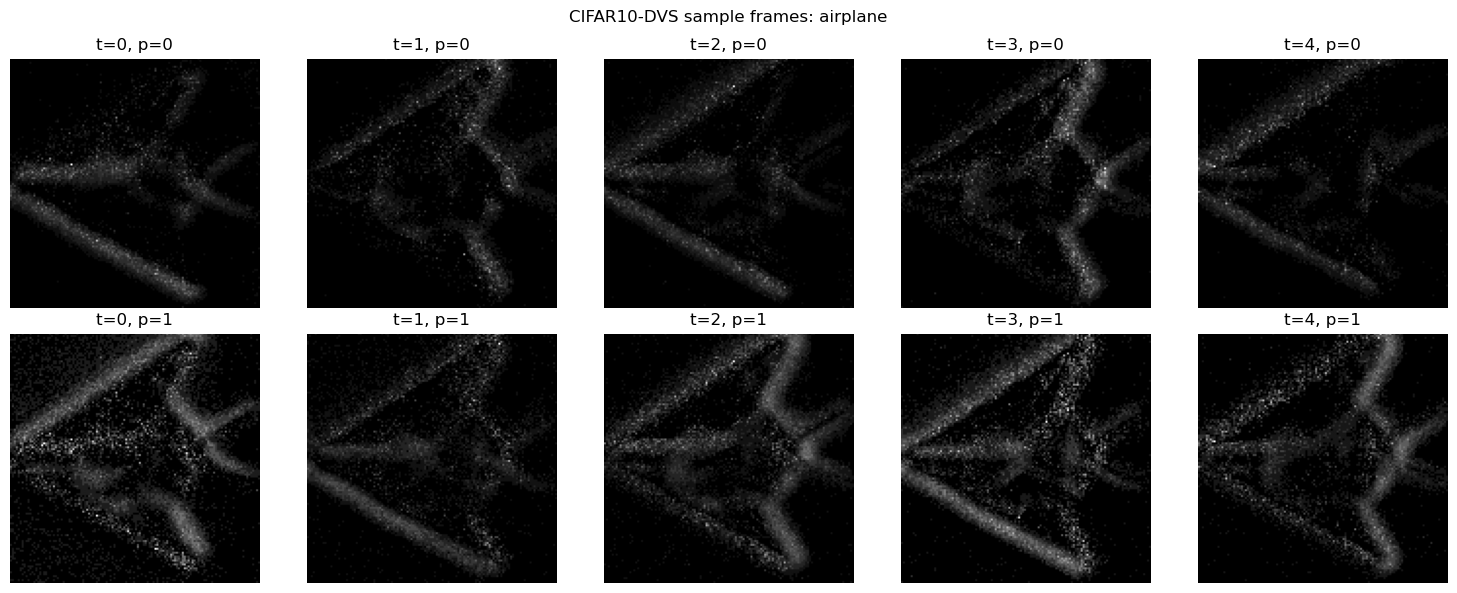

In [11]:
def show_frame_grid(frames_tensor, class_name, max_time_steps=5):
    time_steps = min(frames_tensor.shape[0], max_time_steps)
    num_polarities = frames_tensor.shape[1]

    figure, axes = plt.subplots(
        nrows=num_polarities,
        ncols=time_steps,
        figsize=(3 * time_steps, 3 * num_polarities),
        squeeze=False,
    )

    for polarity_index in range(num_polarities):
        for time_index in range(time_steps):
            axis = axes[polarity_index][time_index]
            image = frames_tensor[time_index, polarity_index]
            axis.imshow(image, cmap="gray")
            axis.set_title(f"t={time_index}, p={polarity_index}")
            axis.axis("off")

    figure.suptitle(f"CIFAR10-DVS sample frames: {class_name}")
    figure.tight_layout()
    plt.show()


show_frame_grid(frames.numpy(), class_names[frame_target])

## Notes

- The current baseline uses `n_time_bins=10` to build a simple dense frame representation.
- Later notebooks can compare alternative preprocessing choices such as different time bin counts or event-count-based slicing.
- The dataset is expected under `data/raw/`, managed by Tonic.